In [1]:
from Bio.PDB import PDBParser, Superimposer, PDBIO
from Bio import PDB
import numpy as np
import mdtraj as md
import glob
import pandas as pd
import seaborn as sns
import math
import random
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import itertools
from sklearn.preprocessing import MinMaxScaler
import sklearn

In [2]:
def magnitude(vector):
    return math.sqrt(sum(pow(element, 2) for element in vector))

Constant values

In [3]:
path = 'selected_pdbs/*.pdb'
pca = PCA(2)
lambda_min = 0
lambda_max = 1
number_of_sections = 100
intervals = 5    # you may change this interval to get different values for lambdas

Combinations of lambda

In [4]:
interval_size = (lambda_max - lambda_min) / (intervals - 1)
lambda_values = [lambda_min + i * interval_size for i in range(intervals)]
x = y = z = lambda_values
lambda123 = [i for i in itertools.product(x, y, z) if sum(i) == 1]
print("Values for each lambdas", lambda_values)

Values for each lambdas [0.0, 0.25, 0.5, 0.75, 1.0]


Measure Kernel values for different lambdas for every trajectory

In [21]:
for l in range(len(lambda123)):
    result_for_each_lambda = []
    for name in glob.glob(path):
        parser = PDB.PDBParser()
        io = PDB.PDBIO()
        struct = parser.get_structure(name,name)
        kernel_for_each_lambda = []
        for model in struct:
            for chain in model:
                for residue in chain:
                    for atom in residue:
                        residue_name = residue.resname
                        residue_id = residue.id
                        atom_name = atom.name
                        x,y,z = atom.get_coord()
                        xyz_cord = (x, y, z)
                        r = magnitude(np.array(xyz_cord))
                        kernel = (lambda123[l][0]*((np.cos(x/r))**2))+(lambda123[l][1]*((np.cos(y/r))**2))+(lambda123[l][2]*((np.sin(z/r))**2))
                        kernel_for_each_lambda.append(kernel)
        traj = md.load(name)
        lbl_kernel = md.compute_contacts(traj, [[100, 201]], scheme='ca')[0][0][0]
        
        result_for_each_lambda.append((kernel_for_each_lambda, lbl_kernel))
        
    df = pd.DataFrame(result_for_each_lambda)
    
    np.save(str(lambda123[l][0])+str(lambda123[l][1])+str(lambda123[l][2])+".npy", df)
    print(lambda123[l])

(0.0, 0.0, 1.0)
(0.0, 0.25, 0.75)
(0.0, 0.5, 0.5)
(0.0, 0.75, 0.25)
(0.0, 1.0, 0.0)
(0.25, 0.0, 0.75)
(0.25, 0.25, 0.5)
(0.25, 0.5, 0.25)
(0.25, 0.75, 0.0)
(0.5, 0.0, 0.5)
(0.5, 0.25, 0.25)
(0.5, 0.5, 0.0)
(0.75, 0.0, 0.25)
(0.75, 0.25, 0.0)
(1.0, 0.0, 0.0)


In [25]:
labels = []
kernels = []
lambdas = []
for i in range(len(results_for_all_lambda)):
    kernels.append([(sublist[0]) for sublist in results_for_all_lambda[i][0]])
    labels.append([(sublist[1]*10) for sublist in results_for_all_lambda[i][0]])
    lambdas.append(results_for_all_lambda[i][-1])

In [16]:
results = []

for i in range(len(kernels)):
    
    knl = "Kernel = (("+str(lambdas[i][0])+")*((np.cos(x/r))**2))+(("+str(lambdas[i][1])+")*((np.cos(y/r))**2))+(("+str(lambdas[i][2])+")*((np.sin(z/r))**2)))"

    pca_values = pca.fit_transform(kernels[i])
    PC1 = [sublist[0] for sublist in pca_values]
    PC2 = [sublist[1] for sublist in pca_values]
    
    PC1_slice = (max(PC1)-min(PC1))/number_of_sections

    PC1_tick = []
    for j in range(number_of_sections+1):
        PC1_tick.append(min(PC1)+j*PC1_slice)
        
    PC1_ranges = []
    for k in range(len(PC1_tick)):
        PC1_ranges.append((PC1_tick[k-1], PC1_tick[k]))
        
    PC1_deltas = PC1_ranges[1:]
    
    indices_within_PC1_sections = []
    for m in range(len(PC1_deltas)):
        indices_within_each_PC1_section = []
        for n in range(len(PC1)):
            if PC1_deltas[m][0]<=PC1[n]<PC1_deltas[m][1]:
                indices_within_each_PC1_section.append(n)
        if len(indices_within_each_PC1_section)!=0:
            indices_within_PC1_sections.append(indices_within_each_PC1_section)
        
    features_PC1 = []
    for p in range(len(indices_within_PC1_sections)):
        features_within_each_PC1_section = []
        for r in range(len(indices_within_PC1_sections[p])):
            features_within_each_PC1_section.append(labels[0][indices_within_PC1_sections[p][r]])
        features_PC1.append(features_within_each_PC1_section)

    avg_feature_each_PC1_section = [np.mean(items) for items in features_PC1]
    
    coefficients = np.polyfit(list(range(len(avg_feature_each_PC1_section))), avg_feature_each_PC1_section, 1)
    avg_each_PC1_section_pred = np.polyval(coefficients, list(range(len(avg_feature_each_PC1_section))))
    mean_of_all_PC1_features = np.mean(avg_feature_each_PC1_section)
    ssr = np.sum((avg_feature_each_PC1_section - avg_each_PC1_section_pred)**2)
    sst = np.sum((avg_feature_each_PC1_section - mean_of_all_PC1_features)**2)
    r_squared = 1 - (ssr / sst)
    
    variance_each_section = []
    for s in range(len(features_PC1)):
        values = features_PC1[s]
        mean = sum(values) / len(values)
        squared_diffs = [(x - mean) ** 2 for x in values]
        var = sum(squared_diffs) / len(values)
        variance_each_section.append(var)

    slope = round(abs(coefficients[0]), 5)
    R2 = round(r_squared,5)
    variance = round(np.mean(variance_each_section),5)
    ratio = round((slope*R2)/(variance**0.5),5)
    
    results.append((i, knl, "Slope, R_squared, Avg_Variance, Ratio", slope, R2, variance, ratio))

Display and save the best Kernel result

In [17]:
Ordered_Kernel_ratio = sorted(results, key=lambda x: x[-1], reverse=True)
(Ordered_Kernel_ratio[0])

(9,
 'Kernel = ((0.5)*((np.cos(x/r))**2))+((0.0)*((np.cos(y/r))**2))+((0.5)*((np.sin(z/r))**2)))',
 'Slope, R_squared, Avg_Variance, Ratio',
 0.01443,
 0.96058,
 0.00934,
 0.14343)

In [19]:
pca_values = pca.fit_transform(np.array(data))
PC1 = [sublist[0] for sublist in pca_values]
PC2 = [sublist[1] for sublist in pca_values]

PC1_slice = (max(PC1)-min(PC1))/number_of_sections

PC1_tick = []
for j in range(number_of_sections+1):
    PC1_tick.append(min(PC1)+j*PC1_slice)

PC1_ranges = []
for k in range(len(PC1_tick)):
    PC1_ranges.append((PC1_tick[k-1], PC1_tick[k]))

PC1_deltas = PC1_ranges[1:]

indices_within_PC1_sections = []
for m in range(len(PC1_deltas)):
    indices_within_each_PC1_section = []
    for n in range(len(PC1)):
        if PC1_deltas[m][0]<=PC1[n]<PC1_deltas[m][1]:
            indices_within_each_PC1_section.append(n)
    if len(indices_within_each_PC1_section)!=0:
        indices_within_PC1_sections.append(indices_within_each_PC1_section)

features_PC1 = []
for p in range(len(indices_within_PC1_sections)):
    features_within_each_PC1_section = []
    for r in range(len(indices_within_PC1_sections[p])):
        features_within_each_PC1_section.append(lbl[indices_within_PC1_sections[p][r]])
    features_PC1.append(features_within_each_PC1_section)

avg_feature_each_PC1_section = [np.mean(items) for items in features_PC1]

coefficients = np.polyfit(list(range(len(avg_feature_each_PC1_section))), avg_feature_each_PC1_section, 1)
avg_each_PC1_section_pred = np.polyval(coefficients, list(range(len(avg_feature_each_PC1_section))))
mean_of_all_PC1_features = np.mean(avg_feature_each_PC1_section)
ssr = np.sum((avg_feature_each_PC1_section - avg_each_PC1_section_pred)**2)
sst = np.sum((avg_feature_each_PC1_section - mean_of_all_PC1_features)**2)
r_squared = 1 - (ssr / sst)

variance_each_section = []
for s in range(len(features_PC1)):
    values = features_PC1[s]
    mean = sum(values) / len(values)
    squared_diffs = [(x - mean) ** 2 for x in values]
    var = sum(squared_diffs) / len(values)
    variance_each_section.append(var)

slope = round(abs(coefficients[0]), 5)
R2 = round(r_squared,5)
variance = round(np.mean(variance_each_section),5)
ratio = round((slope*R2)/(variance**0.5),5)

print( "Slope, R_squared, Avg_Variance, Ratio", slope, R2, variance, ratio)

Slope, R_squared, Avg_Variance, Ratio 0.13801 0.94413 0.94841 0.1338


for revision

In [15]:
databest = np.load('0.750.00.25.npy', allow_pickle=True)

In [16]:
data = []
lbl = []
for i in range(len(databest)):
    data.append(databest[i][0])
    lbl.append(databest[i][1]*10)

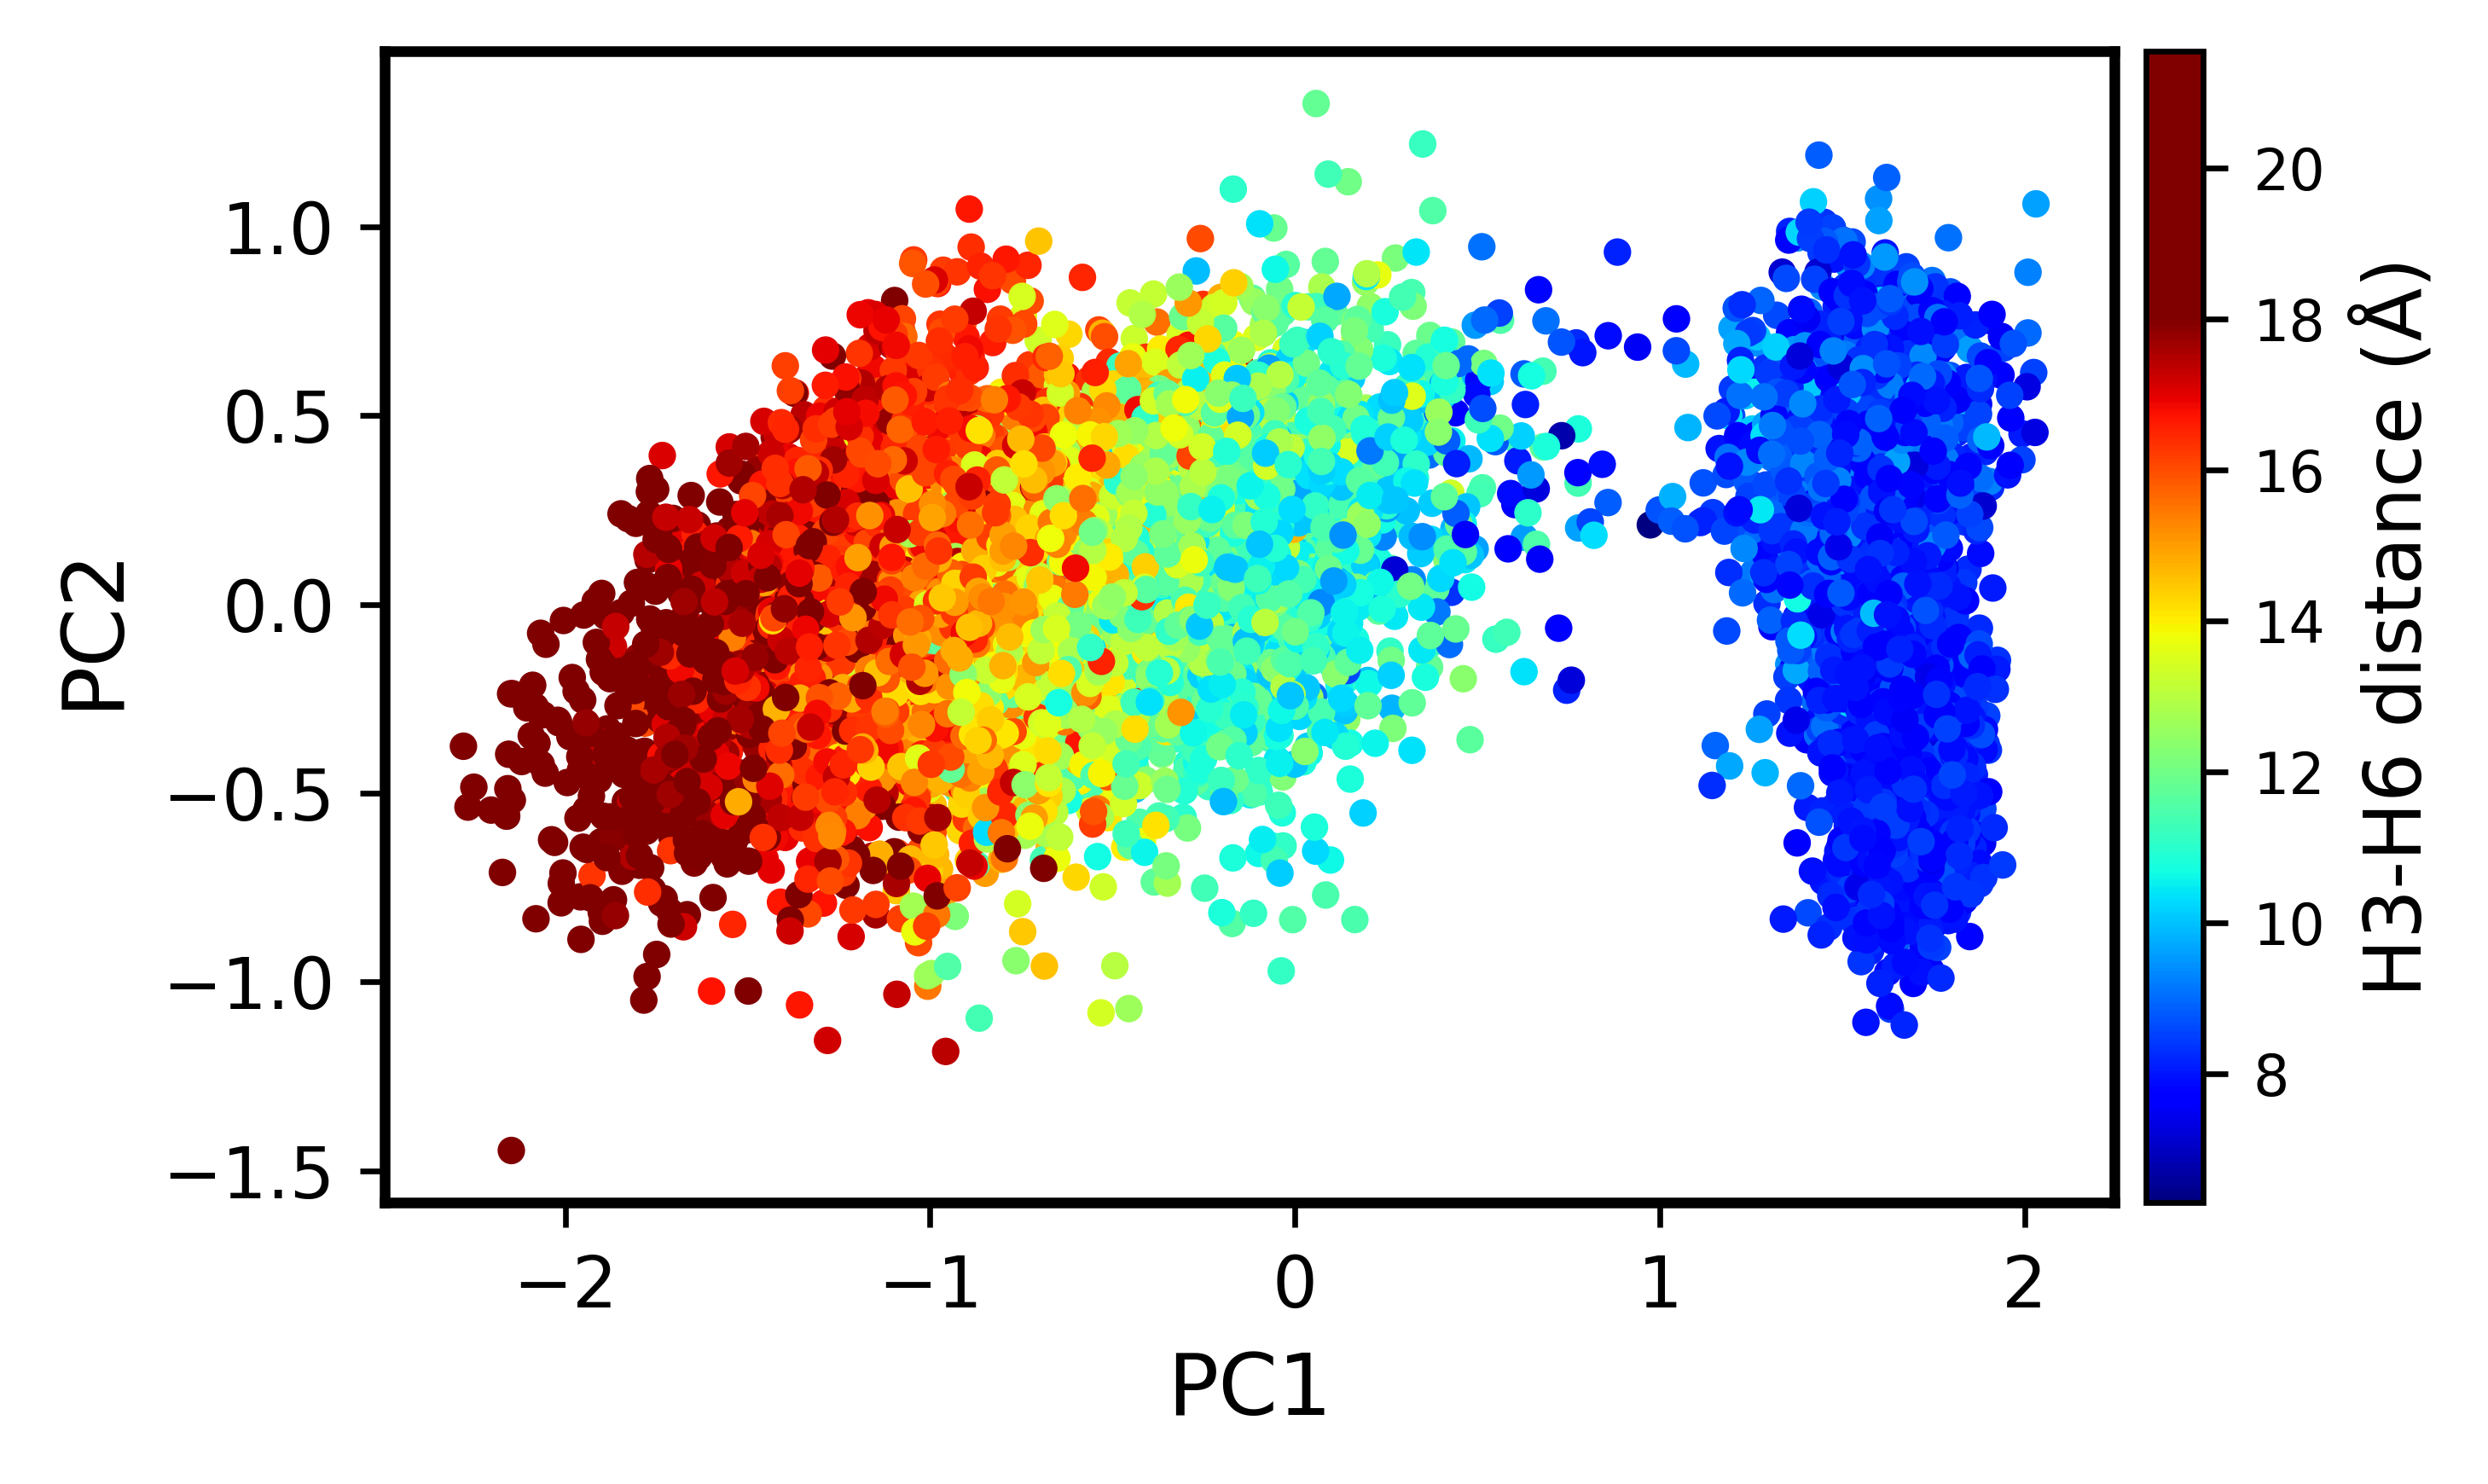

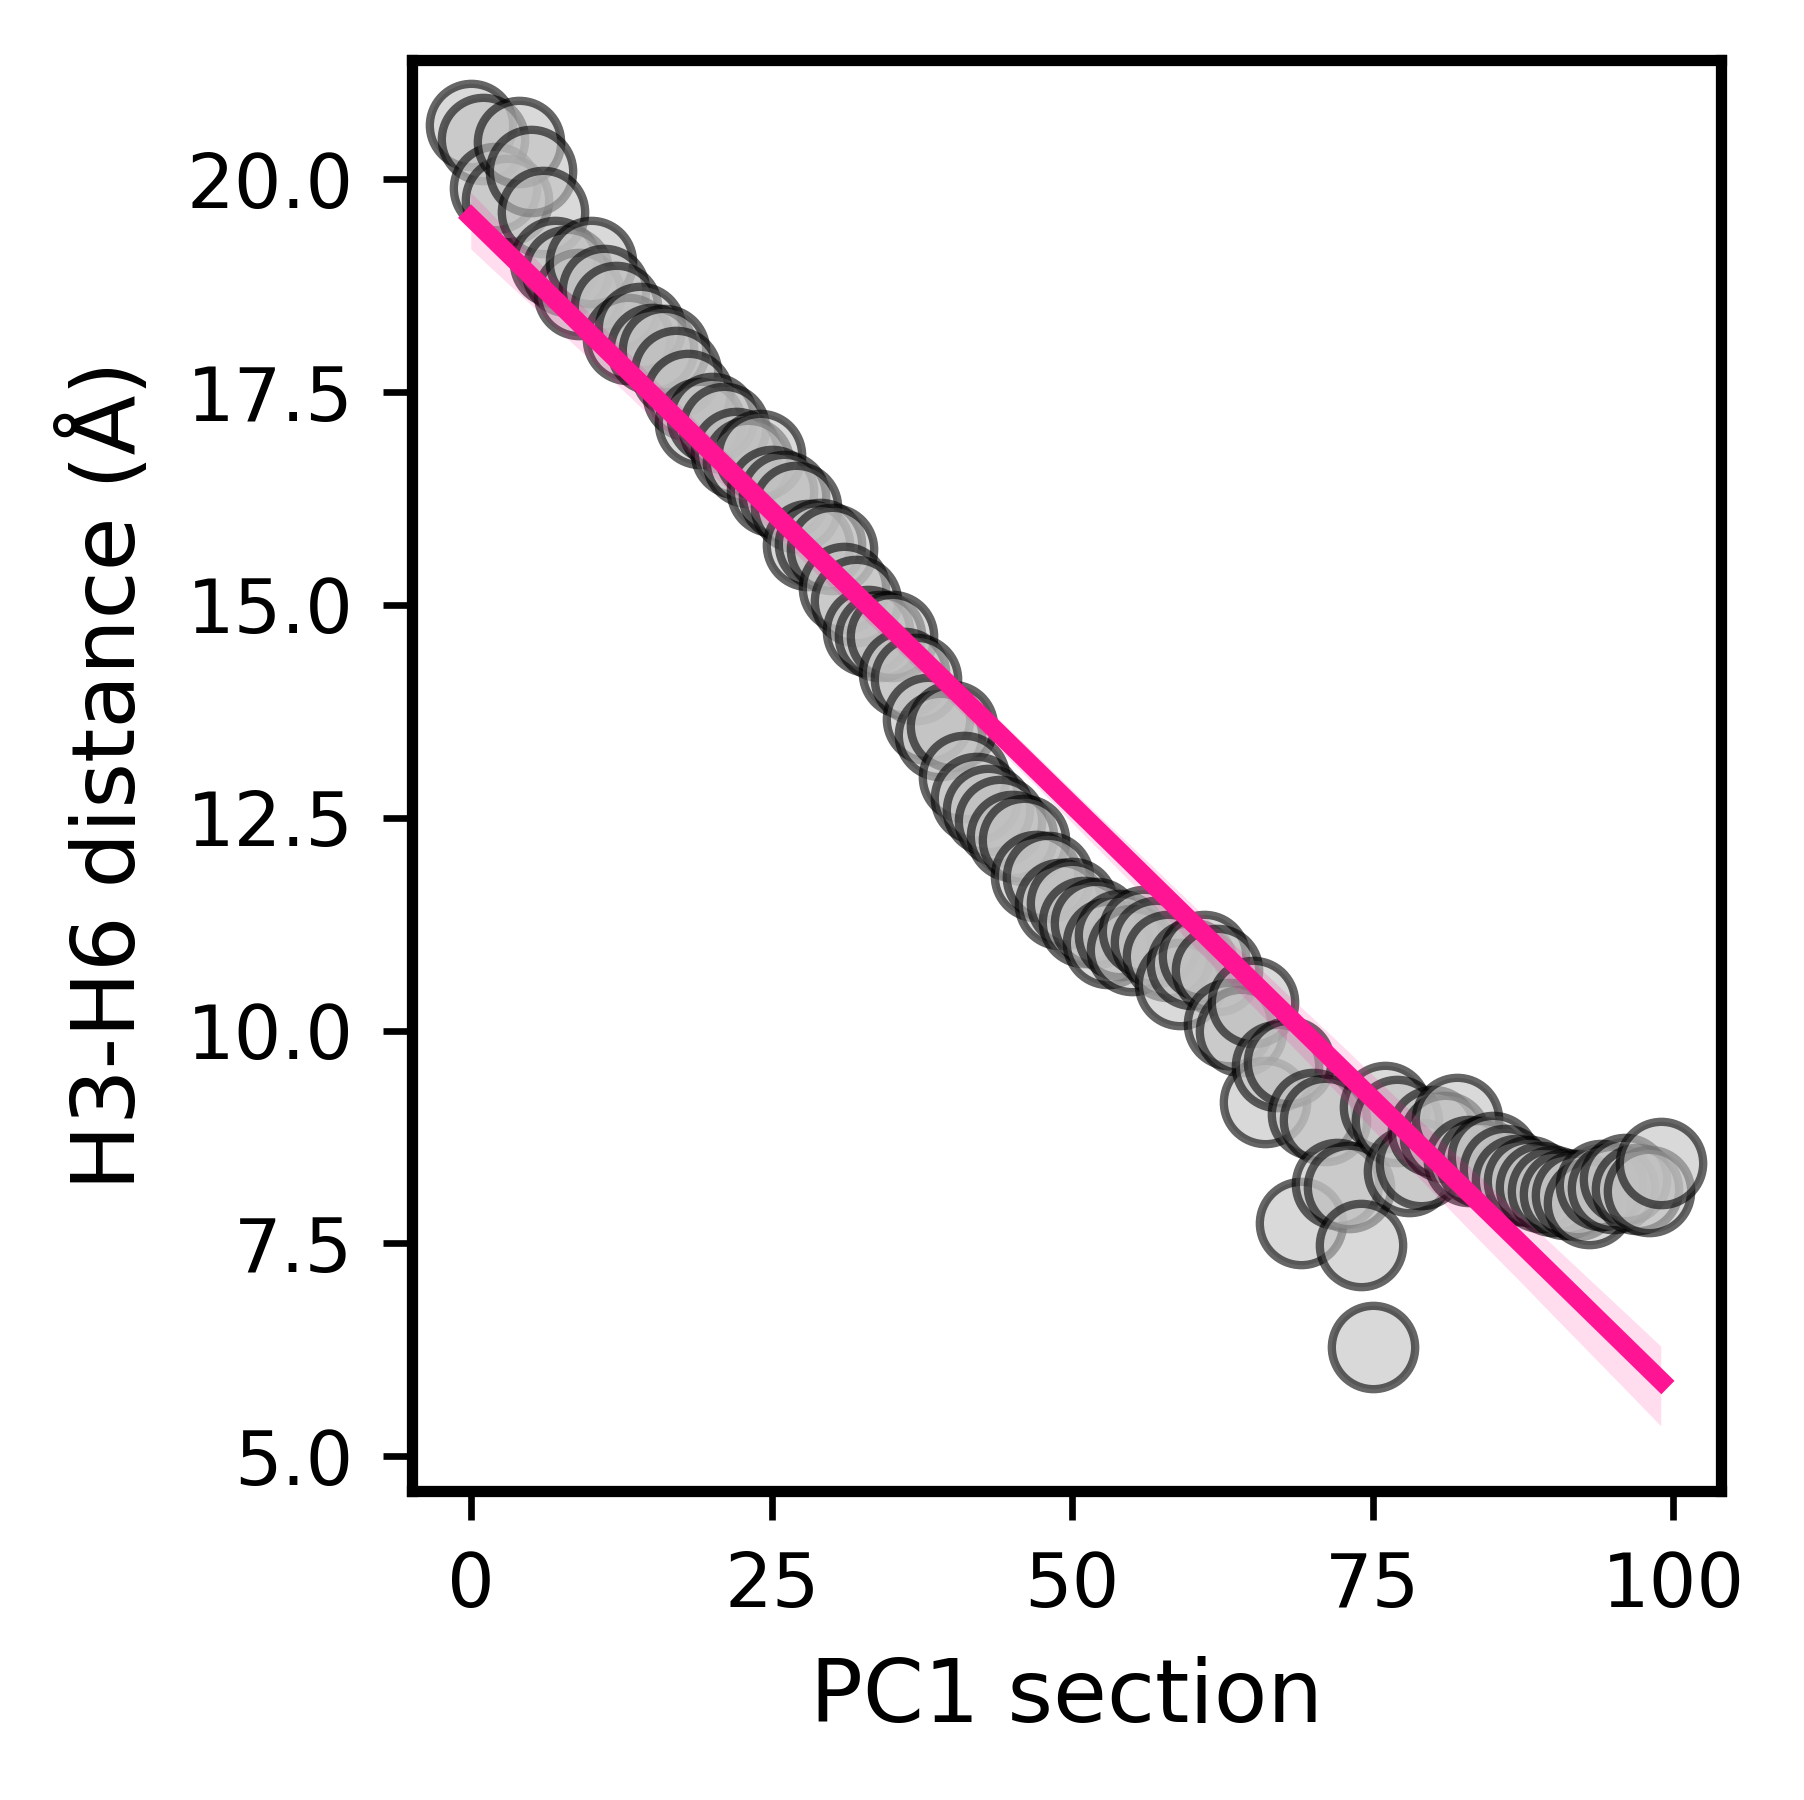

In [9]:
pca_values = pca.fit_transform(data)
PC1 = [sublist[0] for sublist in pca_values]
PC2 = [sublist[-1] for sublist in pca_values]


width = 1.5
fig, ax = plt.subplots(figsize = [5,3], dpi = 600)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(width)
tick_width = 0.5

colors = plt.cm.jet(np.linspace(0,1.3, 500))
custom_cmap = LinearSegmentedColormap.from_list("custom_jet", colors, 500)

scatter = ax.scatter(PC1,PC2,s=15, c=lbl, cmap=custom_cmap, edgecolor='none')
cbar = plt.colorbar(scatter, pad=0.015)
cbar.ax.tick_params(labelsize=8)
cbar.set_label("H3-H6 distance (Å)", fontsize=11)
plt.xlabel('PC1', fontsize = 12)
plt.ylabel('PC2', fontsize = 12)  
plt.tight_layout()
plt.show()

PC1_slice = (max(PC1)-min(PC1))/number_of_sections

PC1_tick = []
for j in range(number_of_sections+1):
    PC1_tick.append(min(PC1)+j*PC1_slice)

PC1_ranges = []
for k in range(len(PC1_tick)):
    PC1_ranges.append((PC1_tick[k-1], PC1_tick[k]))

PC1_deltas = PC1_ranges[1:]

indices_within_PC1_sections = []
for m in range(len(PC1_deltas)):
    indices_within_each_PC1_section = []
    for n in range(len(PC1)):
        if PC1_deltas[m][0]<=PC1[n]<PC1_deltas[m][1]:
            indices_within_each_PC1_section.append(n)
    if len(indices_within_each_PC1_section)!=0:
        indices_within_PC1_sections.append(indices_within_each_PC1_section)

features_PC1 = []
for p in range(len(indices_within_PC1_sections)):
    features_within_each_PC1_section = []
    for r in range(len(indices_within_PC1_sections[p])):
        features_within_each_PC1_section.append(lbl[indices_within_PC1_sections[p][r]])
    features_PC1.append(features_within_each_PC1_section)

avg_feature_each_PC1_section = [np.mean(items) for items in features_PC1]

coefficients = np.polyfit(list(range(len(avg_feature_each_PC1_section))), avg_feature_each_PC1_section, 1)
avg_each_PC1_section_pred = np.polyval(coefficients, list(range(len(avg_feature_each_PC1_section))))
mean_of_all_PC1_features = np.mean(avg_feature_each_PC1_section)
ssr = np.sum((avg_feature_each_PC1_section - avg_each_PC1_section_pred)**2)
sst = np.sum((avg_feature_each_PC1_section - mean_of_all_PC1_features)**2)
r_squared = 1 - (ssr / sst)

variance_each_section = []
for s in range(len(features_PC1)):
    values = features_PC1[s]
    mean = sum(values) / len(values)
    squared_diffs = [(x - mean) ** 2 for x in values]
    var = sum(squared_diffs) / len(values)
    variance_each_section.append(var)

slope = round(abs(coefficients[0]), 5)
R2 = round(r_squared,5)
variance = round(np.mean(variance_each_section),5)
ratio = round((slope*R2)/(variance**0.5),5)

width = 1.35
fig, ax = plt.subplots(figsize = [3.1,3.1], dpi = 600)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(width)
tick_width = 0.5
sns.regplot(x=list(range(len(avg_feature_each_PC1_section))), y=avg_feature_each_PC1_section,  order=1, line_kws={"color": "deeppink"}, scatter_kws=dict(alpha=0.6, s=100, color='silver', edgecolors='black'))
#plt.title([str(Ordered_Kernel_ratio[0])], fontsize = 3.7)
plt.xlabel('PC1 section', fontsize = 10.5)
plt.ylabel('H3-H6 distance (Å)', fontsize = 10.5)  
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

Structural features

In [10]:
coor_dataset = []
for name in glob.glob(path):
    parser = PDB.PDBParser()
    io = PDB.PDBIO()
    struct = parser.get_structure(name,name)
    res_atom_coordinates = []
    for model in struct:
        for chain in model:
            for residue in chain:
                for atom in residue:
                    residue_name = residue.resname
                    residue_id = residue.id
                    atom_name = atom.name
                    if atom_name=="CA":
                        x,y,z = atom.get_coord()
                        xyz_cord = (x, y, z)
                        r = magnitude(np.array(xyz_cord))
                        tta = np.arccos(z/r)
                        res_atom_coordinates.append(tta)
    coor_dataset.append(res_atom_coordinates)
    if len(coor_dataset)%1000 == 0:
        print(len(coor_dataset))

1000
2000
3000
4000
5000
6000
7000
8000
9000
10000


In [11]:
path_atom = 'beta2_8080.pdb'

In [18]:
parser = PDB.PDBParser()
io = PDB.PDBIO()
struct = parser.get_structure(name,name)
residues_atoms = []
for model in struct:
    for chain in model:
        for residue in chain:
            for atom in residue:
                residue_name = residue.resname
                residue_id = residue.id
                atom_name = atom.name
                if atom_name=="CA":
                    residues_atoms.append(str(residue_name)+str(residue_id[1])+'-'+str(atom_name))

In [19]:
zipped_tta = list(zip(*coor_dataset))

In [20]:
results_atoms = []
for i in range(len(zipped_tta)):
    norm_single_atom = sklearn.preprocessing.minmax_scale(zipped_tta[i], feature_range=(0, 1), axis=0)
    features_PC1_atoms = []
    for p in range(len(indices_within_PC1_sections)):
        q = []
        for r in range(len(indices_within_PC1_sections[p])):
            q.append(norm_single_atom[indices_within_PC1_sections[p][r]])
        features_PC1_atoms.append(q)

    avg_feature_each_PC1_section_atoms = [np.mean(items) for items in features_PC1_atoms]

    coefficients_atoms = np.polyfit(list(range(len(avg_feature_each_PC1_section_atoms))), avg_feature_each_PC1_section_atoms, 1)
    avg_each_PC1_section_pred_atoms = np.polyval(coefficients_atoms, list(range(len(avg_feature_each_PC1_section_atoms))))
    mean_of_all_PC1_features_atoms = np.mean(avg_feature_each_PC1_section_atoms)
    ssr_atoms = np.sum((avg_feature_each_PC1_section_atoms - avg_each_PC1_section_pred_atoms)**2)
    sst_atoms = np.sum((avg_feature_each_PC1_section_atoms - mean_of_all_PC1_features_atoms)**2)
    r_squared_atoms = 1 - (ssr_atoms / sst_atoms)

    variance_each_section_atoms = []
    for s in range(len(features_PC1_atoms)):
        values_atoms = features_PC1_atoms[s]
        mean_atoms = sum(values_atoms) / len(values_atoms)
        squared_diffs_atoms = [(x - mean_atoms) ** 2 for x in values_atoms]
        var_atoms = sum(squared_diffs_atoms) / len(values_atoms)
        variance_each_section_atoms.append(var_atoms)

    slope_atoms = round(abs(coefficients_atoms[0]), 5)
    R2_atoms = round(r_squared_atoms,5)
    variance_atoms = round(np.mean(variance_each_section_atoms),5)
    ratio_atoms = round((slope_atoms*R2_atoms)/(variance_atoms**0.5),5)

    results_atoms.append((i, residues_atoms[i], "Slope, R_squared, Avg_Variance, Ratio", slope_atoms, R2_atoms, variance_atoms, ratio_atoms))

In [21]:
Ordered_atm = sorted(results_atoms, key=lambda x: x[-1], reverse=True)
Ordered_atm

[(200,
  'ALA271-CA',
  'Slope, R_squared, Avg_Variance, Ratio',
  0.00834,
  0.99292,
  0.00168,
  0.20203),
 (201,
  'LEU272-CA',
  'Slope, R_squared, Avg_Variance, Ratio',
  0.00923,
  0.9877,
  0.00259,
  0.17913),
 (198,
  'HIS269-CA',
  'Slope, R_squared, Avg_Variance, Ratio',
  0.00826,
  0.98685,
  0.00212,
  0.17704),
 (197,
  'GLU268-CA',
  'Slope, R_squared, Avg_Variance, Ratio',
  0.00896,
  0.98318,
  0.00315,
  0.15696),
 (199,
  'LYS270-CA',
  'Slope, R_squared, Avg_Variance, Ratio',
  0.00702,
  0.97326,
  0.00209,
  0.14945),
 (202,
  'LYS273-CA',
  'Slope, R_squared, Avg_Variance, Ratio',
  0.0082,
  0.99223,
  0.00347,
  0.13812),
 (196,
  'LYS267-CA',
  'Slope, R_squared, Avg_Variance, Ratio',
  0.00785,
  0.98397,
  0.00316,
  0.13741),
 (204,
  'LEU275-CA',
  'Slope, R_squared, Avg_Variance, Ratio',
  0.00877,
  0.98274,
  0.00679,
  0.10459),
 (205,
  'GLY276-CA',
  'Slope, R_squared, Avg_Variance, Ratio',
  0.00802,
  0.97892,
  0.00679,
  0.09528),
 (203,
  'TH

In [28]:
first_most_corr = pd.DataFrame(zipped_tta[200])
second_most_corr = pd.DataFrame(zipped_tta[201])
lbl = pd.DataFrame(labels[0])

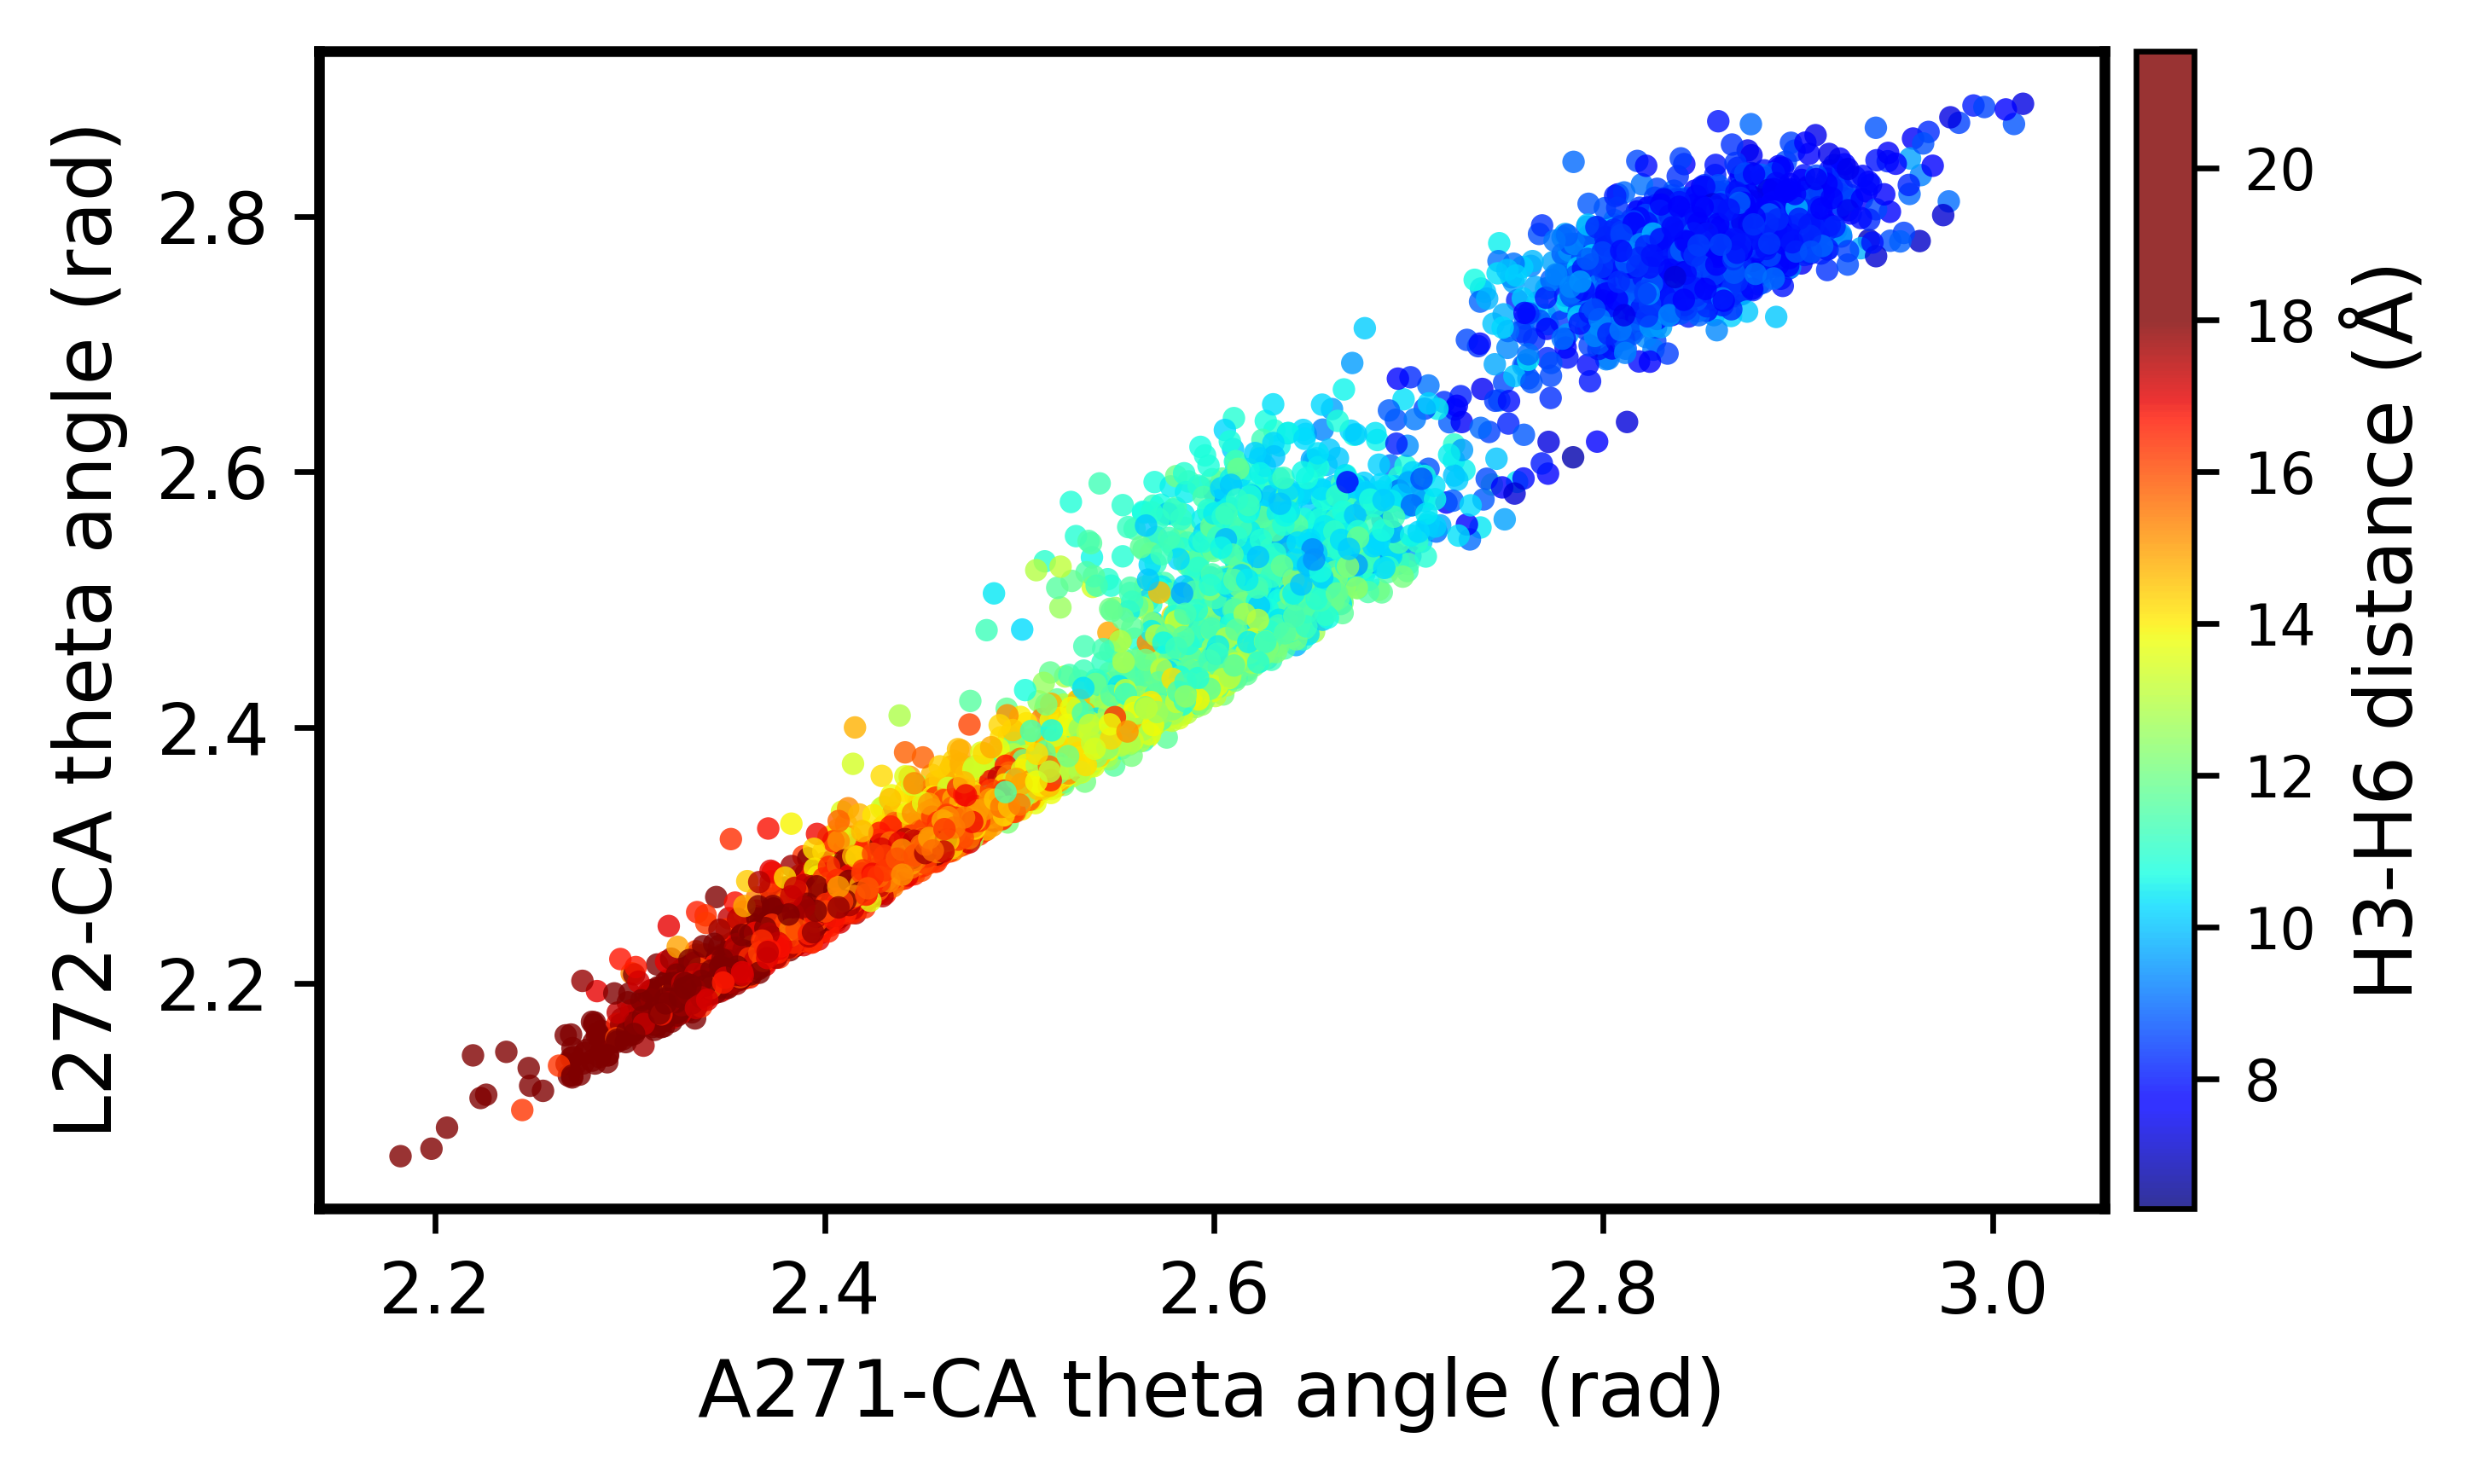

In [42]:
width = 1.5
fig, ax = plt.subplots(figsize = [5,3], dpi = 600)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(width)
tick_width = 0.5

colors = plt.cm.jet(np.linspace(0,1.3, 500))
custom_cmap = LinearSegmentedColormap.from_list("custom_jet", colors, 500)
scatter = ax.scatter(first_most_corr,second_most_corr,s=10, c=lbl, cmap=custom_cmap, edgecolor='none', alpha=0.8)

cbar = plt.colorbar(scatter, pad=0.015)
cbar.ax.tick_params(labelsize=8)
cbar.set_label("H3-H6 distance (Å)", fontsize=11)

plt.xlabel('A271-CA theta angle (rad)', fontsize = 11)
plt.ylabel('L272-CA theta angle (rad)', fontsize = 11)  
plt.tight_layout()
plt.savefig("/Users/parisamollaei/Desktop/Figure for paper/beta2_theta_top_2atom.png") 
plt.show()